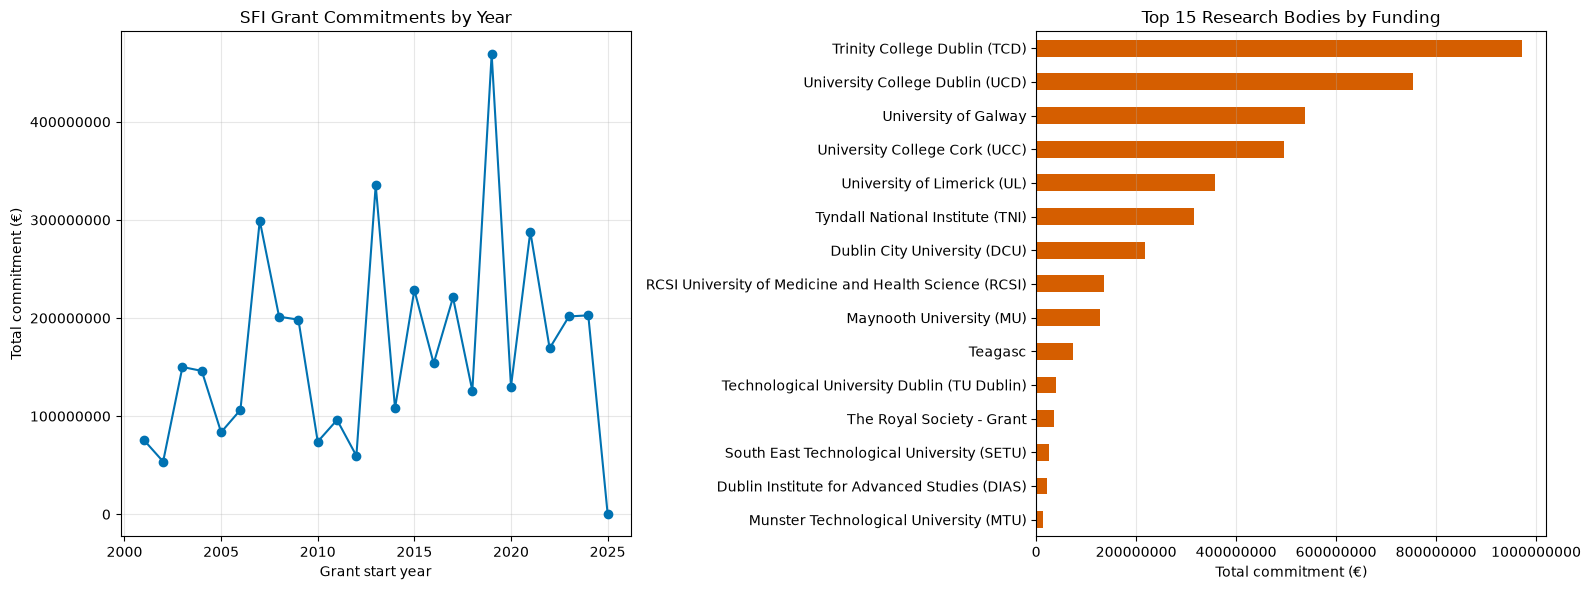

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-02-24/sfi_grants.csv"
sfi_grants = pd.read_csv(url, parse_dates=["start_date"])

sfi_grants["current_total_commitment"] = pd.to_numeric(
    sfi_grants["current_total_commitment"], errors="coerce"
)

annual_funding = (
    sfi_grants.assign(year=sfi_grants["start_date"].dt.year)
    .groupby("year")["current_total_commitment"]
    .sum()
)

top_institutes = (
    sfi_grants.groupby("research_body")["current_total_commitment"]
    .sum()
    .nlargest(15)
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

annual_funding.plot(ax=axes[0], marker="o", color="#0072B2")
axes[0].set_title("SFI Grant Commitments by Year")
axes[0].set_xlabel("Grant start year")
axes[0].set_ylabel("Total commitment (€)")
axes[0].ticklabel_format(axis="y", style="plain")
axes[0].grid(alpha=0.3)

top_institutes.plot.barh(ax=axes[1], color="#D55E00")
axes[1].set_title("Top 15 Research Bodies by Funding")
axes[1].set_xlabel("Total commitment (€)")
axes[1].set_ylabel("")
axes[1].ticklabel_format(axis="x", style="plain")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()